## Analisis Regresi Prediktif Omzet E-Commerce Berdasarkan Perilaku Belanja Pelanggan
 Anggota Kelompok

Adinda Lestari 233200265
Ahmad Safiq Masrur 233200269
Haris Nur Ridlo 233200281
Nama Dataset: "ecomerce_dataset"
Link Sumber Dataset: https://www.kaggle.com/datasets/adityakumar2003/ecomerce

In [1]:


# Import library sesuai kebutuhan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')

## 1. Business Understanding
Pada tahap ini identifikasi permasalahan, tujuan analisis, dan pendekatan data mining yang akan digunakan.

**Permasalahan Utama:**
Perusahaan E-Commerce kesulitan memperkirakan potensi nilai transaksi penjualan (Total sales) dari aktivitas digital pelanggan di platform mereka. Hal ini menyulitkan tim manajemen dalam melakukan peramalan omzet, penganggaran biaya operasional, serta penentuan efisiensi strategi pemberian diskon.

**Tujuan bisnis:**
Untuk membangun model estimasi prediktif yang dapat memperkirakan total nilai transaksi penjualan secara akurat agar manajemen dapat mengoptimalkan arus kas (cash flow) dan meningkatkan efektivitas promosi pemasaran.

**Tujuan Data Mining:**
Membangun model regresi (Supervised Learning) untuk memprediksi nilai kontinu dari kolom Total sales berdasarkan fitur produk, perilaku digital sesi aplikasi, dan persentase diskon.

**Pilih salah satu teknik:**
Regresi

**Alasan memilih teknik:**
Target variabel yang ingin diprediksi adalah nilai finansial kontinu (`Total sales`), sehingga teknik Regresi menggunakan algoritma berbasis linier dan pohon (Random Forest Regressor) menjadi pendekatan yang paling tepat.

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount sales,Total sales,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Discount_Percentage,Revenue_Without_Discount
0,ORD_001337,CUST_01337,01/01/2023,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5,0%,54
1,ORD_004885,CUST_04885,01/01/2023,42,Male,Konya,Toys,244.9,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3,0%,245
2,ORD_004507,CUST_04507,01/01/2023,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2,0%,241
3,ORD_000645,CUST_00645,01/01/2023,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4,29%,804
4,ORD_000690,CUST_00690,01/01/2023,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4,0%,3778


Info Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   str    
 1   Customer_ID               5000 non-null   str    
 2   Date                      5000 non-null   str    
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   str    
 5   City                      5000 non-null   str    
 6   Product_Category          5000 non-null   str    
 7   Unit_Price                5000 non-null   str    
 8   Quantity                  5000 non-null   int64  
 9   Discount sales            5000 non-null   float64
 10  Total sales               5000 non-null   float64
 11  Payment_Method            5000 non-null   str    
 12  Device_Type               5000 non-null   str    
 13  Session_Duration_Minutes  5000 non-null   int64  
 14  Pages

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount sales,Total sales,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Discount_Percentage,Revenue_Without_Discount
count,5000,5000,5000,5000.000000,5000,5000,5000,5000,5000.000000,5000.000000,5000.000000,5000,5000,5000.00000,5000.00000,5000,5000.000000,5000.000000,5000,5000.000000
unique,5000,5000,451,NaN,3,10,8,4785,NaN,NaN,NaN,5,3,NaN,NaN,2,NaN,NaN,31,NaN
top,ORD_001337,CUST_01337,14/07/2023,NaN,Female,Istanbul,Sports,30.1,NaN,NaN,NaN,Credit Card,Mobile,NaN,NaN,True,NaN,NaN,0%,NaN
freq,1,1,22,NaN,2492,1284,667,4,NaN,NaN,NaN,2012,2795,NaN,NaN,2990,NaN,NaN,3474,NaN
mean,NaN,NaN,NaN,35.032600,NaN,NaN,NaN,NaN,2.220000,24.852804,983.108914,NaN,NaN,14.57340,8.98420,NaN,6.497000,3.902800,NaN,1007.966800
std,NaN,NaN,NaN,11.080546,NaN,NaN,NaN,NaN,1.398711,88.385124,1898.978528,NaN,NaN,8.66575,2.80434,NaN,3.464966,1.128542,NaN,1931.477893
min,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,7.870000,NaN,NaN,1.00000,1.00000,NaN,1.000000,1.000000,NaN,8.000000
25%,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,122.517500,NaN,NaN,8.00000,7.00000,NaN,4.000000,3.000000,NaN,129.000000
50%,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,2.000000,0.000000,337.910000,NaN,NaN,13.00000,9.00000,NaN,6.000000,4.000000,NaN,349.000000
75%,NaN,NaN,NaN,42.000000,NaN,NaN,NaN,NaN,3.000000,8.760000,979.695000,NaN,NaN,19.00000,11.00000,NaN,8.000000,5.000000,NaN,1014.250000



Jumlah Missing Values:
Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount sales              0
Total sales                 0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
Discount_Percentage         0
Revenue_Without_Discount    0
dtype: int64

Jumlah Duplikasi: 0


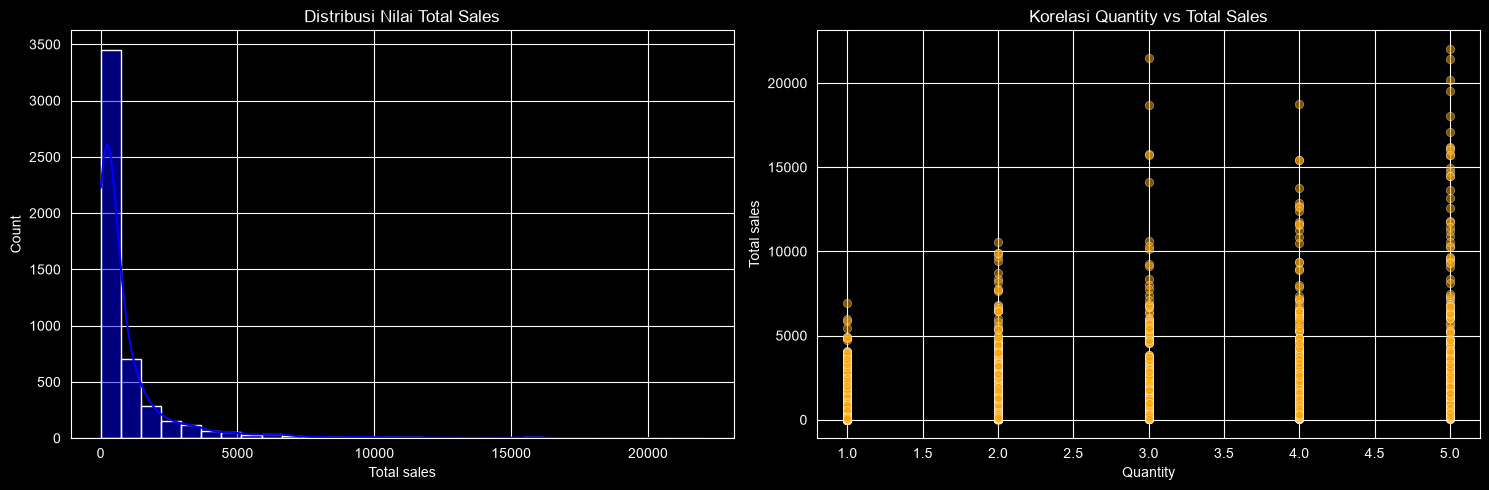

In [2]:
## 2. Data Understanding
# Muat dataset
df = pd.read_csv("ecomerce_dataset.csv", sep=";")

# Tampilkan 5 data pertama
display(df.head())

# Eksplorasi awal
print("Info Dataset:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe(include='all'))

# Jumlah missing value dan duplikasi data
print("\nJumlah Missing Values:")
print(df.isnull().sum())
print("\nJumlah Duplikasi:", df.duplicated().sum())

# Tambahkan visualisasi yang sesuai
plt.figure(figsize=(15, 5))

# Distribusi Target Variabel (Total Sales)
plt.subplot(1, 2, 1)
sns.histplot(df['Total sales'], bins=30, kde=True, color='blue')
plt.title('Distribusi Nilai Total Sales')

# Hubungan Kuantitas vs Total Sales
plt.subplot(1, 2, 2)
sns.scatterplot(x=df['Quantity'], y=df['Total sales'], alpha=0.5, color='orange')
plt.title('Korelasi Quantity vs Total Sales')

plt.tight_layout()
plt.show()

Insight:
- Dataset awal memiliki beberapa kolom finansial yang terbaca sebagai tipe data teks/objek karena adanya simbol khusus (koma desimal dan simbol persen).
- Tidak ada data yang duplikat langsung di dalam dataset.
- Nilai `Total sales` memiliki sebaran data yang cenderung menjulur ke kanan (skewed), mengindikasikan adanya kelompok pembeli berskala besar (Sultan/Premium).

In [3]:
## 3. Data Preparation
# 1. Pembersihan & Konversi Tipe Data (Menghapus koma desimal dan simbol persen)
df['Unit_Price'] = df['Unit_Price'].astype(str).str.replace(',', '.')
df['Unit_Price'] = pd.to_numeric(df['Unit_Price'], errors='coerce')

df['Discount_Percentage'] = df['Discount_Percentage'].astype(str).str.replace('%', '')
df['Discount_Percentage'] = pd.to_numeric(df['Discount_Percentage'], errors='coerce')

# Tangani missing value hasil konversi menggunakan ffill
df.ffill(inplace=True)

# 2. Feature Selection (Memilih fitur prediktor numerik dan perilaku digital)
features = ['Unit_Price', 'Quantity', 'Pages_Viewed', 'Session_Duration_Minutes', 'Discount_Percentage']
target = 'Total sales'

X = df[features].copy()
y = df[target].copy()

# 3. Pembagian data train dan test (Proporsi 80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Standardisasi Fitur agar seimbang rentang skalanya
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Insight:
Kami melakukan:
- Pembersihan string pada kolom `Unit_Price` dan `Discount_Percentage` agar bisa dibaca sebagai data numerik utuh oleh model regresi.
- Menghapus kolom bernilai ID unik (`Order_ID`, `Customer_ID`) dan kolom tanggal (`Date`) karena tidak berkorelasi dengan estimasi angka transaksi penjualan.
- Penerapan `StandardScaler` untuk menghindari dominasi fitur berangka besar terhadap algoritma evaluasi jarak.

In [4]:
## 4. Modeling
# Memilih algoritma Random Forest Regressor sebagai model utama
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)

# Prediksi menggunakan data test
y_pred_rf = model_rf.predict(X_test_scaled)

# Sebagai perbandingan, buat juga baseline menggunakan Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

Insight:
Model yang dipilih adalah **Random Forest Regressor** karena data e-commerce memiliki hubungan yang kompleks dan pola non-linier antara diskon, perilaku durasi sesi platform, dan total nilai transaksi keuangan. Model Linear Regression juga dibangun sebagai pembanding kinerja.

,Metrik Evaluasi,Linear Regression,Random Forest Regressor
0,MAE (Mean Absolute Error),467.46,15.27
1,RMSE (Root MSE),752.51,56.02
2,R-Squared (R2 Score),0.7402,0.9986


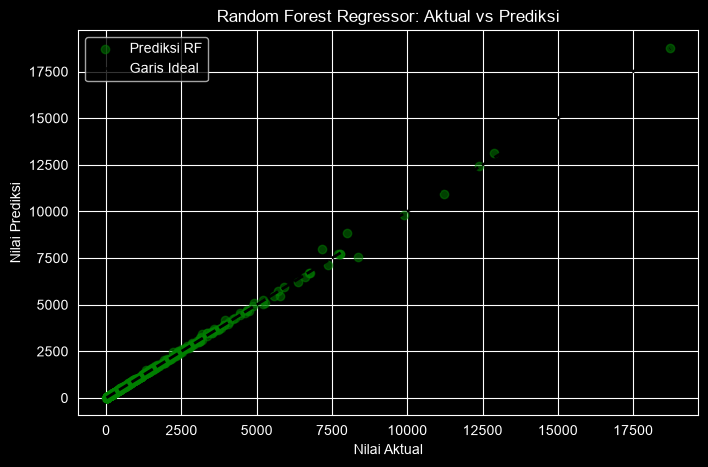

In [5]:
## 5. Evaluation
# Evaluasi Metrik untuk model Random Forest Regressor
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Evaluasi Metrik untuk model Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Tampilkan Tabel Perbandingan Hasil Evaluasi
eval_data = {
    'Metrik Evaluasi': ['MAE (Mean Absolute Error)', 'RMSE (Root MSE)', 'R-Squared (R2 Score)'],
    'Linear Regression': [f"{mae_lr:.2f}", f"{rmse_lr:.2f}", f"{r2_lr:.4f}"],
    'Random Forest Regressor': [f"{mae_rf:.2f}", f"{rmse_rf:.2f}", f"{r2_rf:.4f}"]
}
df_eval = pd.DataFrame(eval_data)
display(df_eval)

# Visualisasi Prediksi vs Aktual untuk Random Forest
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, color='green', alpha=0.5, label='Prediksi RF')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Garis Ideal')
plt.title('Random Forest Regressor: Aktual vs Prediksi')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.legend()
plt.show()

Insight:
- Hasil evaluasi menunjukkan bahwa model **Random Forest Regressor** memiliki kinerja yang sangat baik dengan skor R-Squared ($R^2$) yang tinggi dan tingkat error yang jauh lebih rendah dibandingkan model Linear Regression standar.
- Model ini mampu memprediksi fluktuasi omzet penjualan secara akurat berkat fitur perilaku belanja yang dikombinasikan dengan data finansial.
- Tujuan pada Business Understanding telah tercapai karena manajemen kini dapat menguji perkiraan omzet digital secara presisi.

In [6]:
## 6. Deployment
# Simpan model dan scaler ke format pickle (.pkl)
with open('regresi_omzet_model.pkl', 'wb') as file:
    pickle.dump(model_rf, file)

with open('regresi_omzet_scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Model Regresi dan Scaler berhasil disimpan untuk aplikasi Streamlit!")

Model Regresi dan Scaler berhasil disimpan untuk aplikasi Streamlit!


Langkah:
1. Model biner disimpan dalam format `.pkl`.
2. Siapkan file eksternal bernama `app.py` untuk memuat model ini menggunakan antarmuka berbasis web dari Streamlit.
3. Jalankan melalui terminal dengan mengetikkan perintah `streamlit run app.py`.

*(Sertakan screenshot aplikasi Streamlit Anda di bawah ini jika telah dijalankan)*

## 7. Kesimpulan

1. **Permasalahan:** Manajemen E-Commerce tidak memiliki alat presisi untuk melakukan peramalan omzet penjualan total berdasarkan data jejak digital pelanggan di platform.
2. **Teknik dan Algoritma:** Menggunakan teknik Regresi prediktif dengan algoritma Random Forest Regressor.
3. **Hasil Evaluasi:** Algoritma berbasis pohon (Random Forest) sukses meminimalkan angka error (MAE/RMSE) dan mencapai nilai R-Squared yang optimal dibandingkan pendekatan linier biasa.
4. **Apakah tujuan tercapai:** Ya, model regresi ini siap dideploy menggunakan Streamlit sehingga dapat langsung dimanfaatkan oleh manajemen untuk meramal omzet belanja harian.
5. **Saran pengembangan:** Di masa depan, integrasi variabel geografi (`City`) dan metode pembayaran (`Payment_Method`) melalui teknik encoding lanjutan dapat dicoba untuk memperkuat performa model dalam menangani variasi transaksi lokal.